This is the Challenge solution

In [1]:
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
features = []
labels = []

features = pd.read_csv('train_features.csv')

labels = pd.read_csv('train_labels.csv')

features_validation = pd.read_csv('validation_features.csv')
labels_validation = pd.read_csv('validation_labels.csv')


print(features)
print(labels)


         flow_id  split    start_rel    duration transport  server_port  \
0    flow_000556  train   984.059212    0.279441       udp          443   
1    flow_001329  train  2364.626529    0.288427       udp          443   
2    flow_000888  train  1653.145131    0.405309       udp          443   
3    flow_000892  train  1708.775147    0.403140       udp          443   
4    flow_000862  train  1365.734263    0.429065       udp          443   
..           ...    ...          ...         ...       ...          ...   
242  flow_000462  train   754.775240  160.431876       tcp          443   
243  flow_000918  train  1826.120998  252.103570       tcp          443   
244  flow_000282  train   301.280254  300.530490       tcp          443   
245  flow_001300  train  2225.567423  418.046260       tcp          443   
246  flow_000529  train   975.201123  213.536277       udp          443   

     packet_count_up  packet_count_down  bytes_up  bytes_down  ...  \
0                 27         

Remove the server port

In [2]:
features.drop(columns=features.columns[5], inplace=True)
features_validation.drop(columns=features_validation.columns[5], inplace=True)
features_validation.drop(columns=features_validation.columns[1], inplace=True)
features.drop(columns=features.columns[1], inplace=True)
print(features_validation.head())
print(features.head())

       flow_id    start_rel   duration transport  packet_count_up  \
0  flow_000860  1316.750166   0.283537       udp                3   
1  flow_001305  2266.478566   0.240060       udp                7   
2  flow_000970  1848.510551  21.281612       udp                9   
3  flow_001254  2170.131482   0.229376       udp                4   
4  flow_000051    21.600285  49.595020       tcp               11   

   packet_count_down  bytes_up  bytes_down  mean_pkt_size_up  \
0                  3      3965        3876       1321.666667   
1                  4      9200        1547       1314.285714   
2                  6      5913        4516        657.000000   
3                  6      3074        3565        768.500000   
4                  7      2588        4428        235.272727   

   mean_pkt_size_down  std_pkt_size_up  std_pkt_size_down  mean_iat  \
0         1292.000000        41.955002           0.000000  0.056707   
1          386.750000        32.074531         523.801191 

In [3]:
# Find flow IDs in the feature data that have no matching label
missing_train = features.loc[
    ~features["flow_id"].isin(labels["flow_id"]),
    "flow_id"
]

for flow_id in missing_train:
    print(f"Feature {flow_id} not found in labels")

# Keep only training features with matching labels
features = features[
    features["flow_id"].isin(labels["flow_id"])
].copy()


# Use validation labels for validation features
missing_validation = features_validation.loc[
    ~features_validation["flow_id"].isin(labels_validation["flow_id"]),
    "flow_id"
]

for flow_id in missing_validation:
    print(f"Validation feature {flow_id} not found in labels")

# Keep only validation features with matching labels
features_validation = features_validation[
    features_validation["flow_id"].isin(labels_validation["flow_id"])
].copy()

Convert TCP and UDP to numbers

In [4]:
for dataframe in [features, features_validation]:
    dataframe["transport"] = (
        dataframe["transport"]
        .fillna("unknown")
        .astype(str)
        .str.strip()
        .str.lower()
        .map({
            "tcp": 0,
            "udp": 1,
            "unknown": 2
        })
    )

    if dataframe["transport"].isna().any():
        raise ValueError("Unexpected transport values found")

Feature extraction

In [5]:
# For the training
features['packet_count_diff'] = features.packet_count_up - features.packet_count_down
features['byte_diff'] = features.bytes_up - features.bytes_down
features['packet_count_ratio'] = features.packet_count_up / features.packet_count_down
features['byte_ratio'] = features.bytes_up / features.bytes_down
features['density_up'] = features.bytes_up / features.duration
features['density_down'] = features.bytes_down / features.duration
features['density_ratio'] = features['density_up'] / features['density_down']
features['average_packet_down'] = features.bytes_down / features.packet_count_down
features['average_packet_up'] = features.bytes_up / features.packet_count_up
features['average_packet_ratio'] = features['average_packet_up'] / features['average_packet_down']
features['total_bytes'] = features.bytes_up + features.bytes_down
features['total_packet_count'] = features.packet_count_up + features.packet_count_down
features['upload_ratio'] = features.bytes_up / features.total_bytes
features['download_ratio'] = features.bytes_down / features.total_bytes
features['flow_density'] = features.total_bytes / features.duration
features['iat_cv'] = features['std_iat'] / features['mean_iat']
features['iat_zscore_of_max'] = (features['max_iat'] - features['mean_iat']) / features['std_iat']


# For the validation
features_validation['packet_count_diff'] = features_validation.packet_count_up - features_validation.packet_count_down
features_validation['byte_diff'] = features_validation.bytes_up - features_validation.bytes_down
features_validation['packet_count_ratio'] = features_validation.packet_count_up / features_validation.packet_count_down
features_validation['byte_ratio'] = features_validation.bytes_up / features_validation.bytes_down
features_validation['density_up'] = features_validation.bytes_up / features_validation.duration
features_validation['density_down'] = features_validation.bytes_down / features_validation.duration
features_validation['density_ratio'] = features_validation['density_up'] / features_validation['density_down']
features_validation['average_packet_down'] = features_validation.bytes_down / features_validation.packet_count_down
features_validation['average_packet_up'] = features_validation.bytes_up / features_validation.packet_count_up
features_validation['average_packet_ratio'] = features_validation['average_packet_up'] / features_validation['average_packet_down']
features_validation['total_bytes'] = features_validation.bytes_up + features_validation.bytes_down
features_validation['total_packet_count'] = features_validation.packet_count_up + features_validation.packet_count_down
features_validation['upload_ratio'] = features_validation.bytes_up / features_validation.total_bytes
features_validation['download_ratio'] = features_validation.bytes_down / features_validation.total_bytes
features_validation['flow_density'] = features_validation.total_bytes / features_validation.duration
features_validation['iat_zscore_of_max'] = (features_validation['max_iat'] - features_validation['mean_iat']) / features_validation['std_iat']
features_validation['iat_cv'] = features_validation['std_iat'] / features_validation['mean_iat']

/home/user/Documents/application-inference-packet-flows-public/venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000739 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2346
[LightGBM] [Info] Number of data points in the train set: 247, number of used features: 33
[LightGBM] [Info] Start training from score -3.429947
[LightGBM] [Info] Start training from score -0.924421
[LightGBM] [Info] Start training from score -2.870331
[LightGBM] [Info] Start training from score -2.075401
[LightGBM] [Info] Start training from score -1.502055
[LightGBM] [Info] Start training from score -1.795816
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Wa

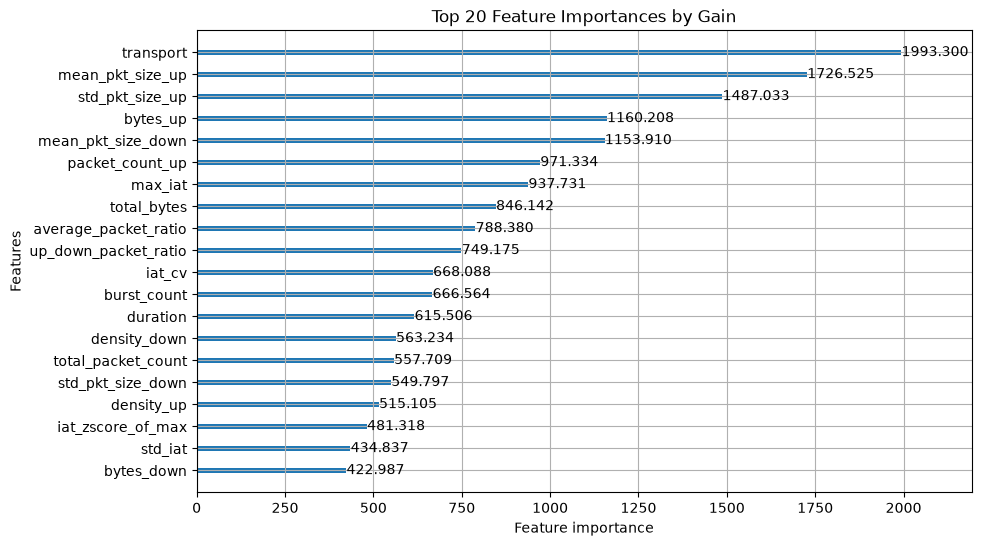

In [6]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score, f1_score, classification_report

for dataframe in [features, features_validation]:
    dataframe.replace([np.inf, -np.inf], np.nan, inplace=True)

# Match each feature row with its label
train_data = features.merge(
    labels[["flow_id", "app"]],
    on="flow_id",
    how="inner",
    validate="one_to_one"
)

validation_data = features_validation.merge(
    labels_validation[["flow_id", "app"]],
    on="flow_id",
    how="inner",
    validate="one_to_one"
)

# Separate input features from target labels
X_train = train_data.drop(columns=["flow_id", "app","start_rel"])
y_train = train_data["app"].astype("category")

X_validation = validation_data.drop(columns=["flow_id", "app","start_rel"])
y_validation = validation_data["app"].astype("category")

# Ensure validation uses the same class encoding as training
y_validation = y_validation.cat.set_categories(y_train.cat.categories)

# Convert labels to 0, 1, ..., number_of_classes - 1
y_train_codes = y_train.cat.codes
y_validation_codes = y_validation.cat.codes


model = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=len(y_train.cat.categories),
    n_estimators=4000,
    learning_rate=0.02,
    num_leaves=31,
    random_state=2026,

)

model.fit(
    X_train,
    y_train_codes,
    eval_set=[(X_validation, y_validation_codes)],
    eval_names=["validation"],
    eval_metric="multi_logloss",
    callbacks=[
        lgb.early_stopping(50),
        lgb.log_evaluation(10)
    ]
)

prediction_codes = model.predict(X_validation).astype(int)

print("Validation accuracy:",
      accuracy_score(y_validation_codes, prediction_codes))

print("Validation macro F1:",
      f1_score(y_validation_codes, prediction_codes, average="macro"))

print(classification_report(
    y_validation_codes,
    prediction_codes,
    target_names=y_train.cat.categories
))

lgb.plot_importance(model, importance_type="gain", max_num_features=20,figsize=(10, 6))
plt.title("Top 20 Feature Importances by Gain")
plt.show()

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'facebook': np.int64(0), 'google': np.int64(1), 'instagram': np.int64(2), 'mozilla': np.int64(3), 'x': np.int64(4), 'youtube': np.int64(5)}


# Change the method slightly 

# Instead of training with the full 20 extract more features extract a lot
# Inlclude stuff like logs and other derived features

# Then use rfecv to select the most important features

# Then train the model using only the selected features.



In [8]:
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import RFECV

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=2022)

rfecv = RFECV(
    estimator=lgb.LGBMClassifier(
        objective="multiclass",
        num_class=len(y_train.cat.categories),
        n_estimators=400,
        learning_rate=0.02,
        num_leaves=32,
        random_state=2022,
        verbosity=-1
    ),
    step=1,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

rfecv.fit(X_train, y_train_codes)

print("Optimal number of features:", rfecv.n_features_)
print("Selected features:", X_train.columns[rfecv.support_])
print("Dropped features:", X_train.columns[~rfecv.support_])

Optimal number of features: 22
Selected features: Index(['duration', 'packet_count_up', 'bytes_up', 'bytes_down',
       'mean_pkt_size_up', 'mean_pkt_size_down', 'std_pkt_size_up',
       'std_pkt_size_down', 'std_iat', 'max_iat', 'burst_count',
       'up_down_packet_ratio', 'up_down_byte_ratio', 'packet_count_diff',
       'byte_diff', 'density_up', 'density_down', 'average_packet_ratio',
       'total_bytes', 'total_packet_count', 'iat_cv', 'iat_zscore_of_max'],
      dtype='str')
Dropped features: Index(['transport', 'packet_count_down', 'mean_iat', 'min_iat',
       'packet_count_ratio', 'byte_ratio', 'density_ratio',
       'average_packet_down', 'average_packet_up', 'upload_ratio',
       'download_ratio', 'flow_density'],
      dtype='str')


In [9]:
x_train_rfecv = X_train.loc[:, rfecv.support_]
x_validation_rfecv = X_validation.loc[:, rfecv.support_]

selected_rfecv_features = X_train.columns[rfecv.support_]

print("Selected features:", selected_rfecv_features.tolist())
print("Number selected:", len(selected_rfecv_features))

model_rfecv = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=len(y_train.cat.categories),
    n_estimators=204,
    learning_rate=0.02,
    num_leaves=12,
    random_state=2022,
    verbosity=-1
)

model_rfecv.fit(
    x_train_rfecv,
    y_train_codes,
    eval_set=[(x_validation_rfecv, y_validation_codes)],
    eval_names=["validation"],
    eval_metric="multi_logloss",
    callbacks=[
        lgb.early_stopping(50),
        lgb.log_evaluation(10)
    ]
)

prediction_codes_rfecv = model_rfecv.predict(x_validation_rfecv).astype(int)

print("Validation accuracy (selected features):",
      accuracy_score(y_validation_codes, prediction_codes_rfecv))

print("Validation macro F1 (selected features):",
      f1_score(y_validation_codes, prediction_codes_rfecv, average="macro"))

print(classification_report(
    y_validation_codes,
    prediction_codes_rfecv,
    target_names=y_train.cat.categories
))

Selected features: ['duration', 'packet_count_up', 'bytes_up', 'bytes_down', 'mean_pkt_size_up', 'mean_pkt_size_down', 'std_pkt_size_up', 'std_pkt_size_down', 'std_iat', 'max_iat', 'burst_count', 'up_down_packet_ratio', 'up_down_byte_ratio', 'packet_count_diff', 'byte_diff', 'density_up', 'density_down', 'average_packet_ratio', 'total_bytes', 'total_packet_count', 'iat_cv', 'iat_zscore_of_max']
Number selected: 22
Training until validation scores don't improve for 50 rounds
[10]	validation's multi_logloss: 1.30227
[20]	validation's multi_logloss: 1.14367
[30]	validation's multi_logloss: 1.02543
[40]	validation's multi_logloss: 0.937177


/home/user/Documents/application-inference-packet-flows-public/venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[50]	validation's multi_logloss: 0.866603
[60]	validation's multi_logloss: 0.827849
[70]	validation's multi_logloss: 0.798488
[80]	validation's multi_logloss: 0.762238
[90]	validation's multi_logloss: 0.72783
[100]	validation's multi_logloss: 0.695991
[110]	validation's multi_logloss: 0.669723
[120]	validation's multi_logloss: 0.649882
[130]	validation's multi_logloss: 0.623393
[140]	validation's multi_logloss: 0.607382
[150]	validation's multi_logloss: 0.593718
[160]	validation's multi_logloss: 0.587817
[170]	validation's multi_logloss: 0.573865
[180]	validation's multi_logloss: 0.561911
[190]	validation's multi_logloss: 0.551412
[200]	validation's multi_logloss: 0.539589
Did not meet early stopping. Best iteration is:
[204]	validation's multi_logloss: 0.536052
Validation accuracy (selected features): 0.8674698795180723
Validation macro F1 (selected features): 0.8135078740712544
              precision    recall  f1-score   support

    facebook       1.00      0.33      0.50         

RFECV accuracy: 0.8674698795180723
RFECV macro F1: 0.8135078740712544


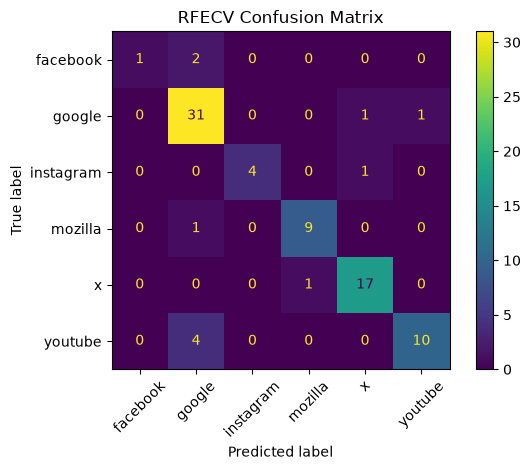

In [10]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

print("RFECV accuracy:",
      accuracy_score(y_validation_codes, prediction_codes_rfecv))
print("RFECV macro F1:",
      f1_score(y_validation_codes, prediction_codes_rfecv, average="macro"))

cm = confusion_matrix(y_validation_codes, prediction_codes_rfecv)

ConfusionMatrixDisplay.from_predictions(
    y_validation_codes,
    prediction_codes_rfecv,
    labels=range(len(y_train.cat.categories)),
    display_labels=y_train.cat.categories,
    xticks_rotation=45
)

plt.title("RFECV Confusion Matrix")
plt.tight_layout()
plt.show()

In [11]:
base_params = {
    "objective": "multiclass",
    "num_class": y_train.nunique(),
    "n_estimators": 300,
    "learning_rate": 0.02,
    "num_leaves": 12,
    "random_state": 2022,
    "verbosity": -1,
    "n_jobs": -1
}

In [12]:
import copy
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

# ------------------------------------------------------------
# 1. Use exactly the RFECV-selected features
# ------------------------------------------------------------

X_train_selected = X_train.reindex(
    columns=selected_rfecv_features
).copy()

X_validation_selected = X_validation.reindex(
    columns=selected_rfecv_features
).copy()

assert X_train_selected.columns.tolist() == (
    X_validation_selected.columns.tolist()
)

print("Selected feature count:", len(selected_rfecv_features))
print("Train/validation columns match: True")


# ------------------------------------------------------------
# 2. Compute inverse-frequency baseline weights
# ------------------------------------------------------------

classes = np.arange(len(le.classes_))
n_samples = len(y_train_codes)
n_classes = len(classes)

class_counts = np.bincount(
    np.asarray(y_train_codes, dtype=int),
    minlength=n_classes
)

baseline_weights = {
    class_code: n_samples / (n_classes * class_counts[class_code])
    for class_code in classes
}

print("\nInverse-frequency baseline weights:")
print(f"{'Code':<8} {'Class':<15} {'Count':>8} {'Weight':>12}")
print("-" * 50)

for class_code in classes:
    print(
        f"{class_code:<8} "
        f"{le.classes_[class_code]:<15} "
        f"{class_counts[class_code]:>8} "
        f"{baseline_weights[class_code]:>12.6f}"
    )


# ------------------------------------------------------------
# 3. Build all ratio combinations
# ------------------------------------------------------------

ratio_values = [0.25 ,0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5]

ratio_combinations = list(
    itertools.product(ratio_values, repeat=n_classes)
)

candidate_class_weights = []

for ratios in ratio_combinations:
    candidate_class_weights.append({
        class_code: baseline_weights[class_code] * ratio
        for class_code, ratio in zip(classes, ratios)
    })

print(
    f"\nTotal possible class-weight combinations: "
    f"{len(candidate_class_weights)}"
)


# ------------------------------------------------------------
# 4. Randomized cross-validation search on training data only
# ------------------------------------------------------------

# Protect against accidentally passing class_weight twice.
search_params = copy.deepcopy(base_params)
search_params.pop("class_weight", None)

estimator = lgb.LGBMClassifier(
    **search_params
)

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=2022
)

search = RandomizedSearchCV(
    estimator=estimator,
    param_distributions={
        "class_weight": candidate_class_weights
    },
    n_iter=150,
    scoring="f1_macro",
    cv=cv,
    random_state=2022,
    n_jobs=-1,
    refit=True,
    return_train_score=False,
    verbose=1
)

# The real validation set is not used here.
search.fit(
    X_train_selected,
    y_train_codes
)


# ------------------------------------------------------------
# 5. Evaluate the winning model on untouched validation data
# ------------------------------------------------------------

best_model = search.best_estimator_
best_weight_dict = search.best_params_["class_weight"]

validation_predictions = best_model.predict(
    X_validation_selected
).astype(int)

validation_f1 = f1_score(
    y_validation_codes,
    validation_predictions,
    average="macro",
    zero_division=0
)

print("\nScore comparison:")
print(f"Best CV macro F1:    {search.best_score_:.6f}")
print(f"Validation macro F1: {validation_f1:.6f}")


# ------------------------------------------------------------
# 6. Print winning weights and ratio multipliers
# ------------------------------------------------------------

print("\nWinning class weights:")
print(
    f"{'Code':<8} {'Class':<15} "
    f"{'Baseline':>12} {'Ratio':>10} {'Final weight':>15}"
)
print("-" * 66)

for class_code in classes:
    final_weight = best_weight_dict[class_code]
    baseline_weight = baseline_weights[class_code]
    ratio = final_weight / baseline_weight

    print(
        f"{class_code:<8} "
        f"{le.classes_[class_code]:<15} "
        f"{baseline_weight:>12.6f} "
        f"{ratio:>10.2f} "
        f"{final_weight:>15.6f}"
    )


# ------------------------------------------------------------
# 7. Classification report with actual class names
# ------------------------------------------------------------

print("\nValidation classification report:")
print(classification_report(
    y_validation_codes,
    validation_predictions,
    labels=classes,
    target_names=le.classes_,
    zero_division=0
))


# ------------------------------------------------------------
# 8. Confusion matrix with actual class names
# ------------------------------------------------------------

print("Validation confusion matrix:")

ConfusionMatrixDisplay.from_predictions(
    y_validation_codes,
    validation_predictions,
    labels=classes,
    display_labels=le.classes_,
    xticks_rotation=45,
    values_format="d"
)

plt.title("Validation Confusion Matrix")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. Print the top 10 candidates by CV score
# ------------------------------------------------------------

cv_results = pd.DataFrame(search.cv_results_)

top_candidates = (
    cv_results
    .sort_values("mean_test_score", ascending=False)
    .head(10)
)

print("\nTop 10 candidates by cross-validation macro F1:")

for rank, (_, row) in enumerate(
    top_candidates.iterrows(),
    start=1
):
    candidate_weights = row["param_class_weight"]

    candidate_ratios = {
        class_code: candidate_weights[class_code]
        / baseline_weights[class_code]
        for class_code in classes
    }

    readable_ratios = {
        le.classes_[class_code]: round(
            candidate_ratios[class_code],
            2
        )
        for class_code in classes
    }

    readable_weights = {
        le.classes_[class_code]: round(
            candidate_weights[class_code],
            6
        )
        for class_code in classes
    }

    print(f"\nRank {rank}")
    print(f"Mean CV macro F1: {row['mean_test_score']:.6f}")
    print(f"CV standard deviation: {row['std_test_score']:.6f}")
    print(f"Ratios: {readable_ratios}")
    print(f"Weights: {readable_weights}")

Selected feature count: 22
Train/validation columns match: True

Inverse-frequency baseline weights:
Code     Class              Count       Weight
--------------------------------------------------
0        facebook               8     5.145833
1        google                98     0.420068
2        instagram             14     2.940476
3        mozilla               31     1.327957
4        x                     55     0.748485
5        youtube               41     1.004065

Total possible class-weight combinations: 1000000
Fitting 3 folds for each of 150 candidates, totalling 450 fits


/home/user/Documents/application-inference-packet-flows-public/venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
# WITHOUT weights (your "regular" baseline)
model_no_weights = lgb.LGBMClassifier(**base_params)
model_no_weights.fit(X_train_selected, y_train_codes)
preds_no_w = model_no_weights.predict(X_validation_selected)

train_preds_no_w = model_no_weights.predict(X_train_selected)
print("NO WEIGHTS — Train macro F1:", f1_score(y_train_codes, train_preds_no_w, average="macro"))
print("NO WEIGHTS — Val macro F1:", f1_score(y_validation_codes, preds_no_w, average="macro"))

# WITH weights (your tuned version)
# y_train_codes contains integer labels, so use integer-keyed weights.
model_weighted = lgb.LGBMClassifier(
	**base_params,
	class_weight=best_weight_dict
)
model_weighted.fit(X_train_selected, y_train_codes)
preds_w = model_weighted.predict(X_validation_selected)

train_preds_w = model_weighted.predict(X_train_selected)
print("WITH WEIGHTS — Train macro F1:", f1_score(y_train_codes, train_preds_w, average="macro"))
print("WITH WEIGHTS — Val macro F1:", f1_score(y_validation_codes, preds_w, average="macro"))

# Train on train + validation, choose models with stratified K-fold

The validation split is merged into training, so it is no longer used to pick models. Instead every candidate is scored with repeated stratified 5-fold CV on all 330 labelled flows, and the best one is refit on everything before predicting the test set.

Load and combine train + validation

In [13]:
import numpy as np
import pandas as pd
import lightgbm as lgb

# Combine train + validation into one labelled set; the validation split
# is no longer held out, model choice is made with stratified K-fold instead.
train_all = pd.concat([
    pd.read_csv('train_features.csv').merge(pd.read_csv('train_labels.csv'), on='flow_id', validate='one_to_one'),
    pd.read_csv('validation_features.csv').merge(pd.read_csv('validation_labels.csv'), on='flow_id', validate='one_to_one'),
], ignore_index=True)

test_features = pd.read_csv('test_features.csv')

print("Combined labelled rows:", len(train_all))
print(train_all['app'].value_counts())
print("Test rows:", len(test_features))

Combined labelled rows: 330
app
google       131
x             73
youtube       55
mozilla       41
instagram     19
facebook      11
Name: count, dtype: int64
Test rows: 81


Feature engineering (same features applied to train+validation and test)

In [14]:
def add_features(dataframe):
    dataframe = dataframe.copy()

    dataframe['transport'] = (
        dataframe['transport'].fillna('unknown').astype(str).str.strip().str.lower()
        .map({'tcp': 0, 'udp': 1, 'unknown': 2})
    )
    if dataframe['transport'].isna().any():
        raise ValueError("Unexpected transport values found")

    dataframe['packet_count_diff'] = dataframe.packet_count_up - dataframe.packet_count_down
    dataframe['byte_diff'] = dataframe.bytes_up - dataframe.bytes_down
    dataframe['density_up'] = dataframe.bytes_up / dataframe.duration
    dataframe['density_down'] = dataframe.bytes_down / dataframe.duration
    dataframe['density_ratio'] = dataframe['density_up'] / dataframe['density_down']
    dataframe['average_packet_ratio'] = dataframe.mean_pkt_size_up / dataframe.mean_pkt_size_down
    dataframe['total_bytes'] = dataframe.bytes_up + dataframe.bytes_down
    dataframe['total_packet_count'] = dataframe.packet_count_up + dataframe.packet_count_down
    dataframe['upload_ratio'] = dataframe.bytes_up / dataframe.total_bytes
    dataframe['flow_density'] = dataframe.total_bytes / dataframe.duration
    dataframe['packet_rate'] = dataframe.total_packet_count / dataframe.duration
    dataframe['burst_rate'] = dataframe.burst_count / dataframe.duration
    dataframe['pkt_size_cv_up'] = dataframe.std_pkt_size_up / dataframe.mean_pkt_size_up
    dataframe['pkt_size_cv_down'] = dataframe.std_pkt_size_down / dataframe.mean_pkt_size_down
    dataframe['iat_cv'] = dataframe['std_iat'] / dataframe['mean_iat']
    dataframe['iat_zscore_of_max'] = (dataframe['max_iat'] - dataframe['mean_iat']) / dataframe['std_iat']

    dataframe.replace([np.inf, -np.inf], np.nan, inplace=True)
    return dataframe


# server_port is constant (443), split/start_rel describe the capture rather than the flow
drop_columns = ['flow_id', 'split', 'server_port', 'start_rel', 'app']

train_all_fe = add_features(train_all)
test_fe = add_features(test_features)

X_all = train_all_fe.drop(columns=drop_columns)
y_all = train_all_fe['app']
X_test = test_fe.drop(columns=[c for c in drop_columns if c != 'app'])

assert X_all.columns.tolist() == X_test.columns.tolist()
print("Feature count:", X_all.shape[1])

Feature count: 33


Compare candidate models with repeated stratified K-fold

In [15]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier, VotingClassifier

lgb_params = dict(
    objective='multiclass',
    n_estimators=300,
    learning_rate=0.03,
    num_leaves=8,
    min_child_samples=3,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.7,
    random_state=2026,
    verbosity=-1,
)

candidate_models = {
    'lgbm': lgb.LGBMClassifier(**lgb_params),
    'lgbm_balanced': lgb.LGBMClassifier(**lgb_params, class_weight='balanced'),
    'random_forest': make_pipeline(
        SimpleImputer(strategy='median'),
        RandomForestClassifier(n_estimators=500, class_weight='balanced_subsample', random_state=2026, n_jobs=-1),
    ),
    'extra_trees': make_pipeline(
        SimpleImputer(strategy='median'),
        ExtraTreesClassifier(n_estimators=500, class_weight='balanced', random_state=2026, n_jobs=-1),
    ),
    'hist_gb': HistGradientBoostingClassifier(learning_rate=0.05, max_leaf_nodes=8, class_weight='balanced', random_state=2026),
}

candidate_models['soft_vote'] = VotingClassifier(
    estimators=[
        ('lgbm', candidate_models['lgbm_balanced']),
        ('rf', candidate_models['random_forest']),
        ('et', candidate_models['extra_trees']),
    ],
    voting='soft',
)

# 5 folds x 3 repeats: every fold keeps the class mix, repeats smooth out the
# split-to-split noise that a single 83-row validation set suffers from.
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=2026)

cv_rows = []
for name, model in candidate_models.items():
    scores = cross_validate(model, X_all, y_all, cv=cv, scoring=['f1_macro', 'accuracy'], n_jobs=1)
    cv_rows.append({
        'model': name,
        'macro_f1_mean': scores['test_f1_macro'].mean(),
        'macro_f1_std': scores['test_f1_macro'].std(),
        'accuracy_mean': scores['test_accuracy'].mean(),
    })
    print(f"{name:15s} macro F1 = {scores['test_f1_macro'].mean():.4f} ± {scores['test_f1_macro'].std():.4f}")

cv_results = pd.DataFrame(cv_rows).sort_values('macro_f1_mean', ascending=False).reset_index(drop=True)
cv_results

lgbm            macro F1 = 0.7355 ± 0.0896
lgbm_balanced   macro F1 = 0.7480 ± 0.0907
random_forest   macro F1 = 0.7366 ± 0.0907
extra_trees     macro F1 = 0.7262 ± 0.0813
hist_gb         macro F1 = 0.7230 ± 0.1012
soft_vote       macro F1 = 0.7565 ± 0.0918


,model,macro_f1_mean,macro_f1_std,accuracy_mean
0,soft_vote,0.756524,0.091778,0.820202
1,lgbm_balanced,0.747974,0.090701,0.811111
2,random_forest,0.736624,0.090695,0.800000
3,lgbm,0.735538,0.089578,0.809091
4,extra_trees,0.726185,0.081308,0.810101
5,hist_gb,0.722981,0.101167,0.784848


Per-class out-of-fold results for the best model

Best model by CV macro F1: soft_vote
              precision    recall  f1-score   support

    facebook      0.857     0.545     0.667        11
      google      0.833     0.840     0.837       131
   instagram      0.824     0.737     0.778        19
     mozilla      0.905     0.927     0.916        41
           x      0.872     0.932     0.901        73
     youtube      0.741     0.727     0.734        55

    accuracy                          0.836       330
   macro avg      0.839     0.785     0.805       330
weighted avg      0.836     0.836     0.834       330



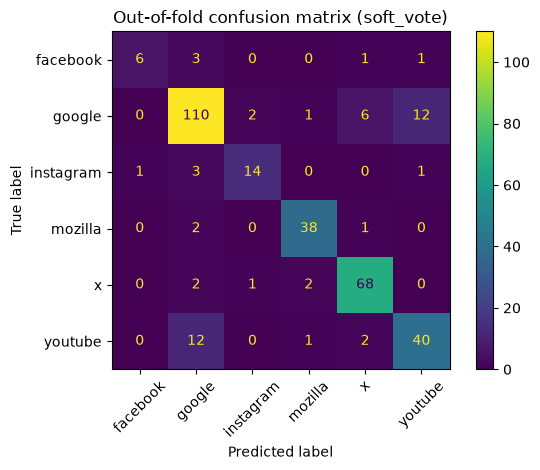

In [16]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_model_name = cv_results.loc[0, 'model']
best_model = candidate_models[best_model_name]
print("Best model by CV macro F1:", best_model_name)

# Out-of-fold predictions give a per-class view of where the best model fails
oof_predictions = cross_val_predict(
    best_model, X_all, y_all,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=2026),
)
print(classification_report(y_all, oof_predictions, digits=3))

ConfusionMatrixDisplay.from_predictions(y_all, oof_predictions, xticks_rotation=45)
plt.title(f"Out-of-fold confusion matrix ({best_model_name})")
plt.tight_layout()
plt.show()

Refit on all labelled data and write the Task 1 submission

In [ ]:
# Refit the chosen model on all train + validation rows and predict the test set
best_model.fit(X_all, y_all)
test_predictions = best_model.predict(X_test)

submission = pd.DataFrame({'flow_id': test_features['flow_id'], 'app': test_predictions})
submission.to_csv('task1_static.csv', index=False)

print(submission['app'].value_counts())
submission.head()